# DRL02 Policy Gradient with PyTorch

### Lab Description

This laboratory develops policy-based reinforcement learning from first principles. We begin with a tabular softmax policy to make action probabilities and the REINFORCE update explicit. We then follow the Hugging Face Deep RL Course Unit 4 workflow: replace the preference table with a PyTorch neural network, train Monte Carlo REINFORCE, and test the same estimator across MiniGrid, CartPole, and PixelCopter.

All agents learn directly from complete trajectories. Visualizations include probability distributions, training curves, direction-dependent policy maps, and animated rollouts for all three environments.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (for example, Ryzen™ AI Max+ PRO 395 or Ryzen™ AI Max 390). The network in this lab is intentionally small and runs efficiently on CPU; a GPU is not required.

#### Software Environment

OS: Ubuntu 24.04 LTS  
Python 3.12 with Gymnasium, MiniGrid, PyTorch, and the PyGame Learning Environment in the AUP Learning Cloud environment.

## Goals

- Distinguish value-based and policy-based reinforcement learning
- Convert policy preferences into action probabilities with softmax
- Explain the log-derivative policy-gradient estimator
- Compute discounted return-to-go from a trajectory
- Implement tabular REINFORCE with a state baseline
- Build and train a stochastic policy network with PyTorch
- Reuse one REINFORCE estimator across symbolic and continuous state vectors
- Train and evaluate policies in MiniGrid, CartPole, and PixelCopter
- Explain why the training loss uses negative return-weighted log probability
- Evaluate stochastic and greedy policies separately
- Inspect learned policy probabilities and GIF rollouts
- Explain why stochastic evaluation can differ from greedy evaluation

## 1. Setup

The setup cell installs only missing packages. Re-running it in an existing AUP Learning Cloud or Colab session does not reinstall packages.

In [1]:
import importlib.util
import contextlib
import io
import os
import site
import subprocess
import sys


os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

required_packages = {
    "gymnasium": "gymnasium",
    "minigrid": "minigrid",
    "imageio": "imageio",
    "ple": "git+https://github.com/ntasfi/PyGame-Learning-Environment.git",
    "torch": "torch",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--user",
            "--quiet",
            "--no-warn-script-location",
            *missing_packages,
        ]
    )
    site.addsitedir(site.getusersitepackages())

from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import minigrid
import numpy as np
import torch
import torch.nn as nn
from IPython.display import Image, display
from torch.distributions import Categorical

with contextlib.redirect_stdout(io.StringIO()):
    from ple import PLE
    from ple.games.pixelcopter import Pixelcopter

torch.set_num_threads(min(4, os.cpu_count() or 1))

print("Python:", sys.version.split()[0])
print("Gymnasium:", gym.__version__)
print("MiniGrid:", minigrid.__version__)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.3
Gymnasium: 1.3.0
MiniGrid: 3.1.0
PyTorch: 2.9.1+rocm7.13.0
NumPy: 2.4.6
Matplotlib: 3.11.0


In [2]:
SEED = 17
ENV_NAME = "MiniGrid-Empty-8x8-v0"
NAV_ACTIONS = np.array([0, 1, 2], dtype=int)
ACTION_NAMES = ("left", "right", "forward")
ACTION_SYMBOLS = ("L", "R", "↑")
DIRECTION_SYMBOLS = ("→", "↓", "←", "↑")
ARTIFACT_DIR = Path("artifacts") / "DRL02"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)


def make_env(render_mode=None):
    return gym.make(ENV_NAME, render_mode=render_mode)


def get_agent_state(env):
    x, y = map(int, env.unwrapped.agent_pos)
    return x, y, int(env.unwrapped.agent_dir)


def stable_softmax(logits, temperature=1.0):
    scaled = np.asarray(logits, dtype=float) / temperature
    shifted = scaled - np.max(scaled)
    probabilities = np.exp(shifted)
    return probabilities / probabilities.sum()


def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    smooth = np.convolve(values, np.ones(window) / window, mode="valid")
    return np.arange(window - 1, len(values)), smooth

## 2. MiniGrid as a Policy-Learning Problem

MiniGrid actions are relative to the agent's orientation. To keep the policy output compact, we use the three navigation actions **left**, **right**, and **forward**. A state is the tuple $(x,y,d)$ containing position and direction.

The full Gymnasium interface remains unchanged:

~~~text
observation, info = env.reset(seed=...)
next_observation, reward, terminated, truncated, info = env.step(action)
~~~

True termination means the agent reached the green goal. Truncation means the time limit ended the episode.

In [3]:
preview_env = make_env()
observation, info = preview_env.reset(seed=SEED)
initial_state = get_agent_state(preview_env)

print("Environment:", ENV_NAME)
print("Observation keys:", tuple(observation.keys()))
print("Full action space:", preview_env.action_space)
print("Policy actions:", dict(enumerate(ACTION_NAMES)))
print("Initial state:", initial_state)
print("Mission:", observation["mission"])
preview_env.close()

Environment: MiniGrid-Empty-8x8-v0
Observation keys: ('image', 'direction', 'mission')
Full action space: Discrete(7)
Policy actions: {0: 'left', 1: 'right', 2: 'forward'}
Initial state: (1, 1, 0)
Mission: get to the green goal square


## 3. From Action Values to a Stochastic Policy

A value-based method represents $Q(s,a)$ and derives a policy by selecting a high-value action. A policy-based method represents the action distribution directly:

$$
\pi_\theta(a\mid s)=P(A_t=a\mid S_t=s;\theta).
$$

For discrete actions, softmax converts unrestricted preferences or logits $h_\theta(s,a)$ into probabilities:

$$
\pi_\theta(a\mid s)
=
\frac{\exp(h_\theta(s,a)/\tau)}
{\sum_b \exp(h_\theta(s,b)/\tau)}.
$$

The temperature $\tau$ controls how concentrated the distribution is. High temperature makes probabilities similar; low temperature approaches greedy selection. Subtracting the largest logit before exponentiation prevents numerical overflow without changing the probabilities.

Unlike ε-greedy exploration, a softmax policy is stochastic by construction. Learning changes the entire distribution rather than switching between a greedy and a random mode.

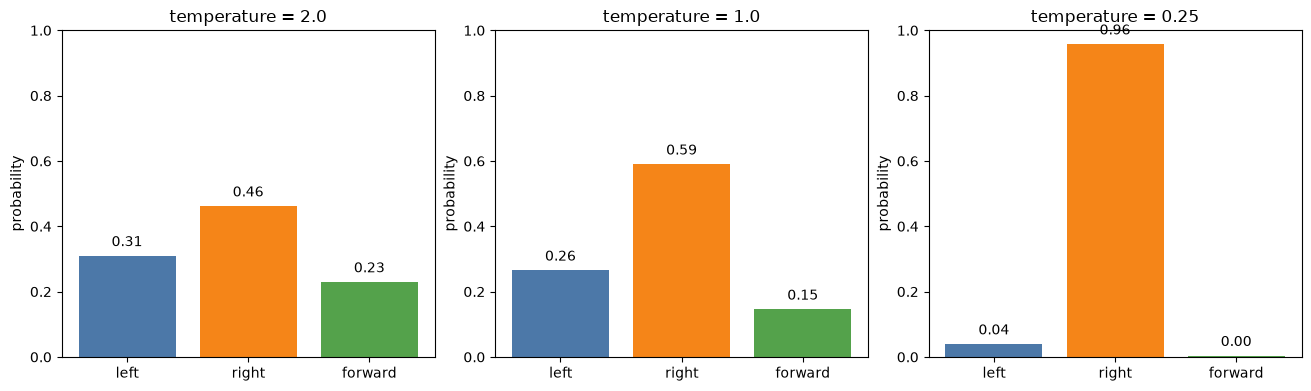

Logits: {'left': np.float64(0.2), 'right': np.float64(1.0), 'forward': np.float64(-0.4)}


In [4]:
example_logits = np.array([0.2, 1.0, -0.4])
temperatures = [2.0, 1.0, 0.25]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
for axis, temperature in zip(axes, temperatures):
    probabilities = stable_softmax(example_logits, temperature)
    axis.bar(ACTION_NAMES, probabilities, color=["#4c78a8", "#f58518", "#54a24b"])
    axis.set_title(f"temperature = {temperature}")
    axis.set_ylim(0, 1)
    axis.set_ylabel("probability")
    for index, probability in enumerate(probabilities):
        axis.text(index, probability + 0.03, f"{probability:.2f}", ha="center")
plt.show()

print("Logits:", dict(zip(ACTION_NAMES, example_logits)))

## 4. Tabular REINFORCE

REINFORCE is a Monte Carlo policy-gradient algorithm. It samples a complete trajectory, computes return-to-go,

$$
G_t = R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots,
$$

and applies the log-derivative estimator

$$
\nabla_\theta J(\theta)
\approx
\sum_t G_t\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$

For tabular softmax preferences, the gradient for one visited state is especially concrete:

$$
\nabla_h\log\pi(A_t\mid S_t)
=
\operatorname{onehot}(A_t)-\pi(\cdot\mid S_t).
$$

We subtract a running state baseline $b(s)$ from $G_t$. The advantage $G_t-b(S_t)$ reduces variance without changing which policy is optimal. Positive advantage increases the sampled action's preference; negative advantage decreases it.

In [5]:
@dataclass
class TabularPolicyResult:
    preferences: np.ndarray
    baselines: np.ndarray
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    successes: np.ndarray
    entropies: np.ndarray


def train_tabular_reinforce(
    episodes=2500,
    alpha=0.10,
    baseline_alpha=0.05,
    gamma=0.99,
    seed=SEED,
):
    env = make_env()
    env.reset(seed=seed)
    width, height = env.unwrapped.width, env.unwrapped.height
    preferences = np.zeros((width, height, 4, len(NAV_ACTIONS)), dtype=float)
    baselines = np.zeros((width, height, 4), dtype=float)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    successes = np.zeros(episodes, dtype=bool)
    entropies = np.zeros(episodes, dtype=float)
    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        env.reset(seed=seed + episode)
        trajectory = []
        terminated = truncated = False

        while not (terminated or truncated):
            state = get_agent_state(env)
            probabilities = stable_softmax(preferences[state])
            local_action = int(rng.choice(len(NAV_ACTIONS), p=probabilities))
            _, reward, terminated, truncated, _ = env.step(
                int(NAV_ACTIONS[local_action])
            )
            trajectory.append(
                (state, local_action, probabilities.copy(), float(reward))
            )

        returns_to_go = np.zeros(len(trajectory), dtype=float)
        discounted_return = 0.0
        for index in reversed(range(len(trajectory))):
            discounted_return = trajectory[index][3] + gamma * discounted_return
            returns_to_go[index] = discounted_return

        trajectory_entropies = []
        for (state, action, probabilities, _), return_to_go in zip(
            trajectory, returns_to_go
        ):
            advantage = return_to_go - baselines[state]
            baselines[state] += baseline_alpha * advantage
            logit_gradient = -probabilities
            logit_gradient[action] += 1.0
            preferences[state] += alpha * advantage * logit_gradient
            trajectory_entropies.append(
                -np.sum(probabilities * np.log(probabilities + 1e-12))
            )

        total_reward = sum(item[3] for item in trajectory)
        episode_returns[episode] = total_reward
        episode_lengths[episode] = len(trajectory)
        successes[episode] = bool(terminated and total_reward > 0)
        entropies[episode] = np.mean(trajectory_entropies)

    env.close()
    return TabularPolicyResult(
        preferences,
        baselines,
        episode_returns,
        episode_lengths,
        successes,
        entropies,
    )

Last-100 reward: 0.948 | success: 100.0% | steps: 14.7


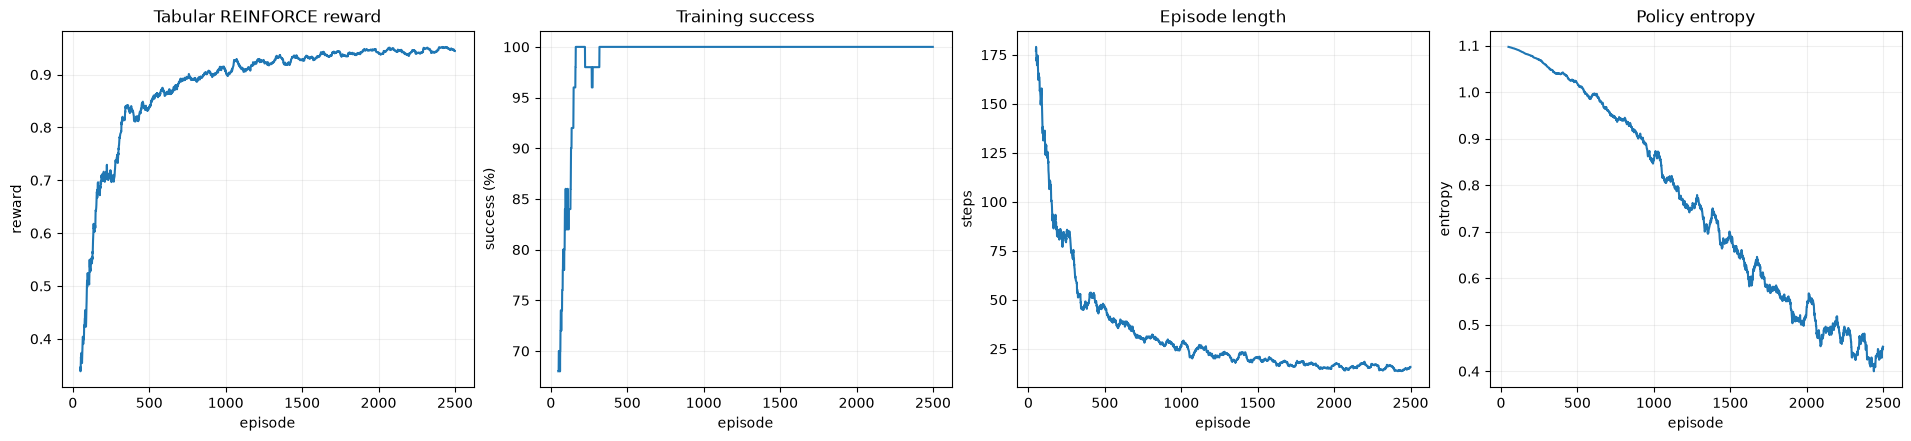

In [6]:
tabular_result = train_tabular_reinforce()

print(
    f"Last-100 reward: {tabular_result.episode_returns[-100:].mean():.3f} | "
    f"success: {100 * tabular_result.successes[-100:].mean():.1f}% | "
    f"steps: {tabular_result.episode_lengths[-100:].mean():.1f}"
)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.3), constrained_layout=True)
metrics = [
    (tabular_result.episode_returns, "reward", "Tabular REINFORCE reward"),
    (
        100 * tabular_result.successes.astype(float),
        "success (%)",
        "Training success",
    ),
    (tabular_result.episode_lengths, "steps", "Episode length"),
    (tabular_result.entropies, "entropy", "Policy entropy"),
]
for axis, (values, ylabel, title) in zip(axes, metrics):
    x_values, smooth_values = moving_average(values, window=50)
    axis.plot(x_values, smooth_values)
    axis.set_title(title)
    axis.set_xlabel("episode")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.2)
plt.show()

### 4.1 Evaluate and visualize the tabular policy

Training samples from the stochastic policy. For evaluation, greedy action selection exposes the most likely action at each state and removes sampling variance. We report both task success and path length, then save one native MiniGrid rollout as a GIF.

Tabular greedy evaluation: reward=0.961, steps=11.00, success=100.0%


Actions: forward → forward → forward → forward → forward → right → forward → forward → forward → forward → forward
Reward=0.961, steps=11, success=True


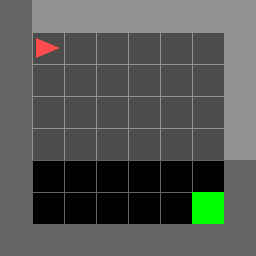

In [7]:
def tabular_policy_rollout(
    preferences,
    seed=0,
    greedy=True,
    capture_frames=False,
):
    env = make_env(render_mode="rgb_array" if capture_frames else None)
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    frames = [env.render().copy()] if capture_frames else []
    actions = []
    total_reward = 0.0
    terminated = truncated = False

    while not (terminated or truncated):
        state = get_agent_state(env)
        probabilities = stable_softmax(preferences[state])
        if greedy:
            candidates = np.flatnonzero(
                np.isclose(probabilities, probabilities.max())
            )
            local_action = int(rng.choice(candidates))
        else:
            local_action = int(rng.choice(len(NAV_ACTIONS), p=probabilities))
        _, reward, terminated, truncated, _ = env.step(
            int(NAV_ACTIONS[local_action])
        )
        actions.append(local_action)
        total_reward += float(reward)
        if capture_frames:
            frames.append(env.render().copy())

    steps = env.unwrapped.step_count
    env.close()
    return {
        "reward": total_reward,
        "steps": steps,
        "success": bool(terminated and total_reward > 0),
        "actions": actions,
        "frames": frames,
    }


tabular_evaluations = [
    tabular_policy_rollout(
        tabular_result.preferences, seed=1000 + episode, greedy=True
    )
    for episode in range(100)
]
print(
    "Tabular greedy evaluation: "
    f"reward={np.mean([item['reward'] for item in tabular_evaluations]):.3f}, "
    f"steps={np.mean([item['steps'] for item in tabular_evaluations]):.2f}, "
    f"success={100 * np.mean([item['success'] for item in tabular_evaluations]):.1f}%"
)

tabular_demo = tabular_policy_rollout(
    tabular_result.preferences,
    seed=2026,
    greedy=True,
    capture_frames=True,
)
tabular_gif = ARTIFACT_DIR / "minigrid_tabular_reinforce.gif"
imageio.mimsave(
    tabular_gif, tabular_demo["frames"], fps=5, loop=0
)
print(
    "Actions:",
    " → ".join(ACTION_NAMES[action] for action in tabular_demo["actions"]),
)
print(
    f"Reward={tabular_demo['reward']:.3f}, steps={tabular_demo['steps']}, "
    f"success={tabular_demo['success']}"
)
display(Image(filename=str(tabular_gif)))

## 5. Policy Gradient with Neural Network

The tabular policy stores an independent preference vector for every $(x,y,d)$. A neural policy replaces that table with shared parameters:

$$
h_\theta(s)=\operatorname{MLP}_\theta(\operatorname{features}(s)),
\qquad
\pi_\theta(\cdot\mid s)=\operatorname{softmax}(h_\theta(s)).
$$

Our feature vector contains normalized $x$ and $y$ coordinates plus a one-hot encoding of the four directions. The network produces three logits for left, right, and forward. A categorical distribution handles both sampling and log-probability calculation.

For gradient ascent on expected return, PyTorch minimizes the equivalent negative objective:

$$
\mathcal{L}_{\text{policy}}
=
-\sum_t G_t\log\pi_\theta(A_t\mid S_t)
-\beta\sum_t\mathcal{H}\bigl(\pi_\theta(\cdot\mid S_t)\bigr).
$$

The entropy term with coefficient $\beta$ discourages the policy from collapsing before it has explored useful trajectories.

In [8]:
def state_features(state, width=8, height=8):
    x, y, direction = state
    features = np.zeros(6, dtype=np.float32)
    features[0] = x / (width - 1)
    features[1] = y / (height - 1)
    features[2 + direction] = 1.0
    return torch.from_numpy(features)


class PolicyNetwork(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, action_size=3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, action_size),
        )

    def forward(self, features):
        return self.network(features)


policy_network = PolicyNetwork()
parameter_count = sum(parameter.numel() for parameter in policy_network.parameters())
with torch.no_grad():
    initial_logits = policy_network(state_features((1, 1, 0)))
    initial_probabilities = torch.softmax(initial_logits, dim=-1)

print(policy_network)
print("Trainable parameters:", parameter_count)
print(
    "Initial action probabilities:",
    {
        name: round(float(probability), 3)
        for name, probability in zip(ACTION_NAMES, initial_probabilities)
    },
)

PolicyNetwork(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
Trainable parameters: 4803
Initial action probabilities: {'left': 0.314, 'right': 0.345, 'forward': 0.341}


### 5.1 Training loop

Each episode performs the following sequence:

1. Sample actions from the current categorical policy.
2. Store each log probability, entropy, and environment reward.
3. Traverse the rewards backward to compute every return-to-go.
4. Construct one differentiable trajectory loss.
5. Call zero_grad(), backward(), gradient clipping, and optimizer.step().

The environment is not differentiable. Gradients flow through the stored log probabilities, not through reset() or step(). Dividing positive returns by their episode maximum rescales the gradient without changing its direction.

In [9]:
@dataclass
class NeuralPolicyResult:
    model: nn.Module
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    successes: np.ndarray
    losses: np.ndarray
    entropies: np.ndarray


def train_pytorch_reinforce(
    episodes=800,
    learning_rate=0.01,
    gamma=0.99,
    entropy_coefficient=0.01,
    seed=SEED,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    env = make_env()
    model = PolicyNetwork()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    successes = np.zeros(episodes, dtype=bool)
    losses = np.zeros(episodes, dtype=float)
    entropies = np.zeros(episodes, dtype=float)

    for episode in range(episodes):
        env.reset(seed=seed + episode)
        log_probabilities = []
        trajectory_entropies = []
        rewards = []
        terminated = truncated = False

        while not (terminated or truncated):
            features = state_features(get_agent_state(env))
            distribution = Categorical(logits=model(features))
            local_action = distribution.sample()
            _, reward, terminated, truncated, _ = env.step(
                int(NAV_ACTIONS[local_action.item()])
            )
            log_probabilities.append(distribution.log_prob(local_action))
            trajectory_entropies.append(distribution.entropy())
            rewards.append(float(reward))

        discounted_return = 0.0
        returns_to_go = []
        for reward in reversed(rewards):
            discounted_return = reward + gamma * discounted_return
            returns_to_go.append(discounted_return)
        returns_to_go = torch.tensor(
            list(reversed(returns_to_go)), dtype=torch.float32
        )
        if returns_to_go.max() > 0:
            returns_to_go = returns_to_go / (returns_to_go.max() + 1e-8)

        log_probability_tensor = torch.stack(log_probabilities)
        entropy_tensor = torch.stack(trajectory_entropies)
        loss = -torch.sum(log_probability_tensor * returns_to_go)
        loss -= entropy_coefficient * torch.sum(entropy_tensor)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_reward = sum(rewards)
        episode_returns[episode] = total_reward
        episode_lengths[episode] = len(rewards)
        successes[episode] = bool(terminated and total_reward > 0)
        losses[episode] = float(loss.detach())
        entropies[episode] = float(entropy_tensor.mean().detach())

        if (episode + 1) % 200 == 0:
            recent_start = max(0, episode - 99)
            recent_slice = slice(recent_start, episode + 1)
            print(
                f"Episode {episode + 1:>4}/{episodes} | "
                f"reward={episode_returns[recent_slice].mean():.3f} | "
                f"success={100 * successes[recent_slice].mean():.1f}% | "
                f"entropy={entropies[recent_slice].mean():.3f}"
            )

    env.close()
    return NeuralPolicyResult(
        model,
        episode_returns,
        episode_lengths,
        successes,
        losses,
        entropies,
    )


neural_result = train_pytorch_reinforce()

Episode  200/800 | reward=0.610 | success=79.0% | entropy=0.445


Episode  400/800 | reward=0.703 | success=91.0% | entropy=0.524


Episode  600/800 | reward=0.846 | success=95.0% | entropy=0.222


Episode  800/800 | reward=0.961 | success=100.0% | entropy=0.009


Last-100 reward: 0.961 | success: 100.0% | steps: 11.0


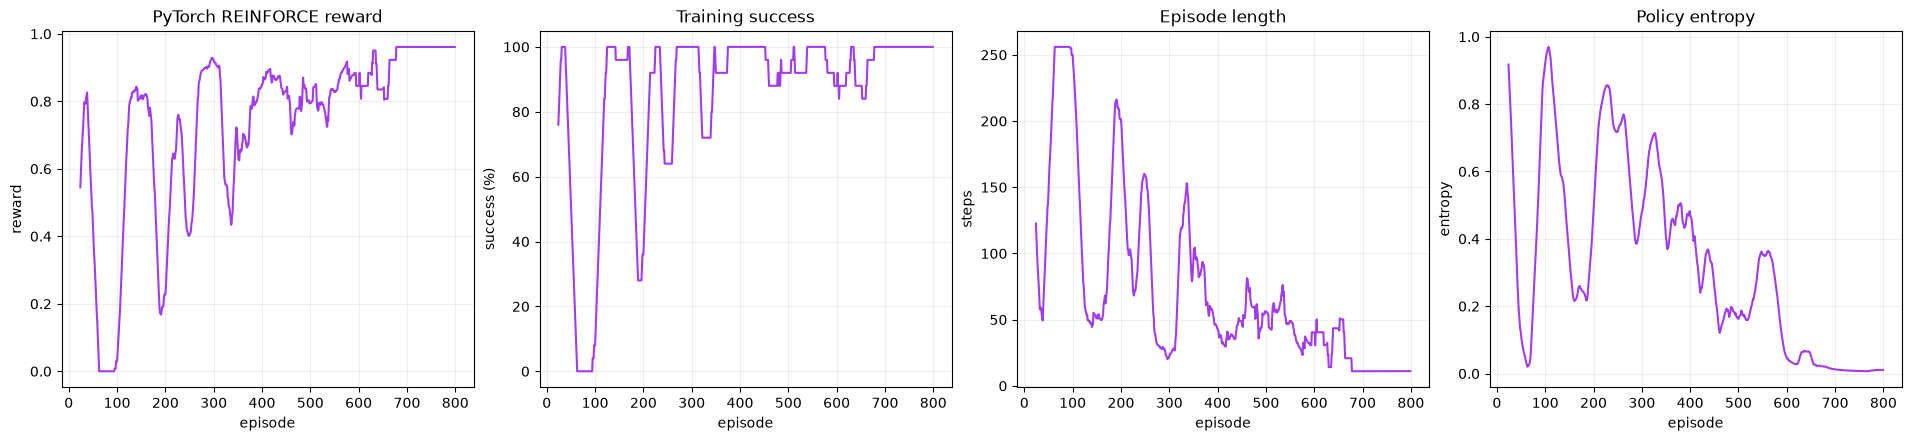

In [10]:
print(
    f"Last-100 reward: {neural_result.episode_returns[-100:].mean():.3f} | "
    f"success: {100 * neural_result.successes[-100:].mean():.1f}% | "
    f"steps: {neural_result.episode_lengths[-100:].mean():.1f}"
)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.3), constrained_layout=True)
neural_metrics = [
    (neural_result.episode_returns, "reward", "PyTorch REINFORCE reward"),
    (
        100 * neural_result.successes.astype(float),
        "success (%)",
        "Training success",
    ),
    (neural_result.episode_lengths, "steps", "Episode length"),
    (neural_result.entropies, "entropy", "Policy entropy"),
]
for axis, (values, ylabel, title) in zip(axes, neural_metrics):
    x_values, smooth_values = moving_average(values, window=25)
    axis.plot(x_values, smooth_values, color="#a23bec")
    axis.set_title(title)
    axis.set_xlabel("episode")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.2)
plt.show()

### 5.2 Stochastic versus greedy evaluation

A policy-gradient agent learns a distribution, so stochastic evaluation is meaningful. It measures the behavior represented during training. Greedy evaluation instead selects the largest-probability action and measures the deterministic mode of that distribution.

Reporting both helps detect a policy that succeeds only because sampling occasionally escapes a poor high-probability action.

In [11]:
def pytorch_policy_rollout(
    model,
    seed=0,
    greedy=True,
    capture_frames=False,
):
    env = make_env(render_mode="rgb_array" if capture_frames else None)
    env.reset(seed=seed)
    torch.manual_seed(seed)
    frames = [env.render().copy()] if capture_frames else []
    actions = []
    total_reward = 0.0
    terminated = truncated = False
    model.eval()

    with torch.no_grad():
        while not (terminated or truncated):
            logits = model(state_features(get_agent_state(env)))
            if greedy:
                local_action = int(torch.argmax(logits).item())
            else:
                local_action = int(Categorical(logits=logits).sample().item())
            _, reward, terminated, truncated, _ = env.step(
                int(NAV_ACTIONS[local_action])
            )
            actions.append(local_action)
            total_reward += float(reward)
            if capture_frames:
                frames.append(env.render().copy())

    steps = env.unwrapped.step_count
    env.close()
    return {
        "reward": total_reward,
        "steps": steps,
        "success": bool(terminated and total_reward > 0),
        "actions": actions,
        "frames": frames,
    }


def evaluate_neural_policy(model, greedy, episodes=100, seed=2000):
    rollouts = [
        pytorch_policy_rollout(model, seed=seed + episode, greedy=greedy)
        for episode in range(episodes)
    ]
    return {
        "reward": np.mean([item["reward"] for item in rollouts]),
        "steps": np.mean([item["steps"] for item in rollouts]),
        "success": np.mean([item["success"] for item in rollouts]),
    }


for greedy in [False, True]:
    metrics = evaluate_neural_policy(neural_result.model, greedy=greedy)
    label = "greedy" if greedy else "stochastic"
    print(
        f"{label:>10}: reward={metrics['reward']:.3f}, "
        f"steps={metrics['steps']:.2f}, "
        f"success={100 * metrics['success']:.1f}%"
    )

stochastic: reward=0.961, steps=11.01, success=100.0%
    greedy: reward=0.961, steps=11.00, success=100.0%


### 5.3 Inspect probability maps

The maps below compare the most probable action and its probability for every non-wall position and direction. Background **hue** identifies the dominant action, while saturation represents its probability: a pale cell is uncertain and a saturated cell is confident. Each label reports both the action symbol and its probability. This avoids mapping every near-deterministic state to the same yellow color.

The tabular policy can memorize independent states. The neural policy produces every decision through shared weights, so nearby states influence one another. On this small sparse-reward task, a successful policy often becomes nearly deterministic; that is not a softmax error. In the default MiniGrid-Empty layout, the fixed start-to-goal shortest path needs only `forward` and one `right` turn, so the neural policy receives no task-driven reason to make `left` dominant. High confidence at states rarely visited during training should therefore be interpreted as neural-network extrapolation, not proof that every displayed decision was directly learned. The printed diagnostics quantify confidence, normalized entropy, and dominant-action counts instead of relying on color alone.

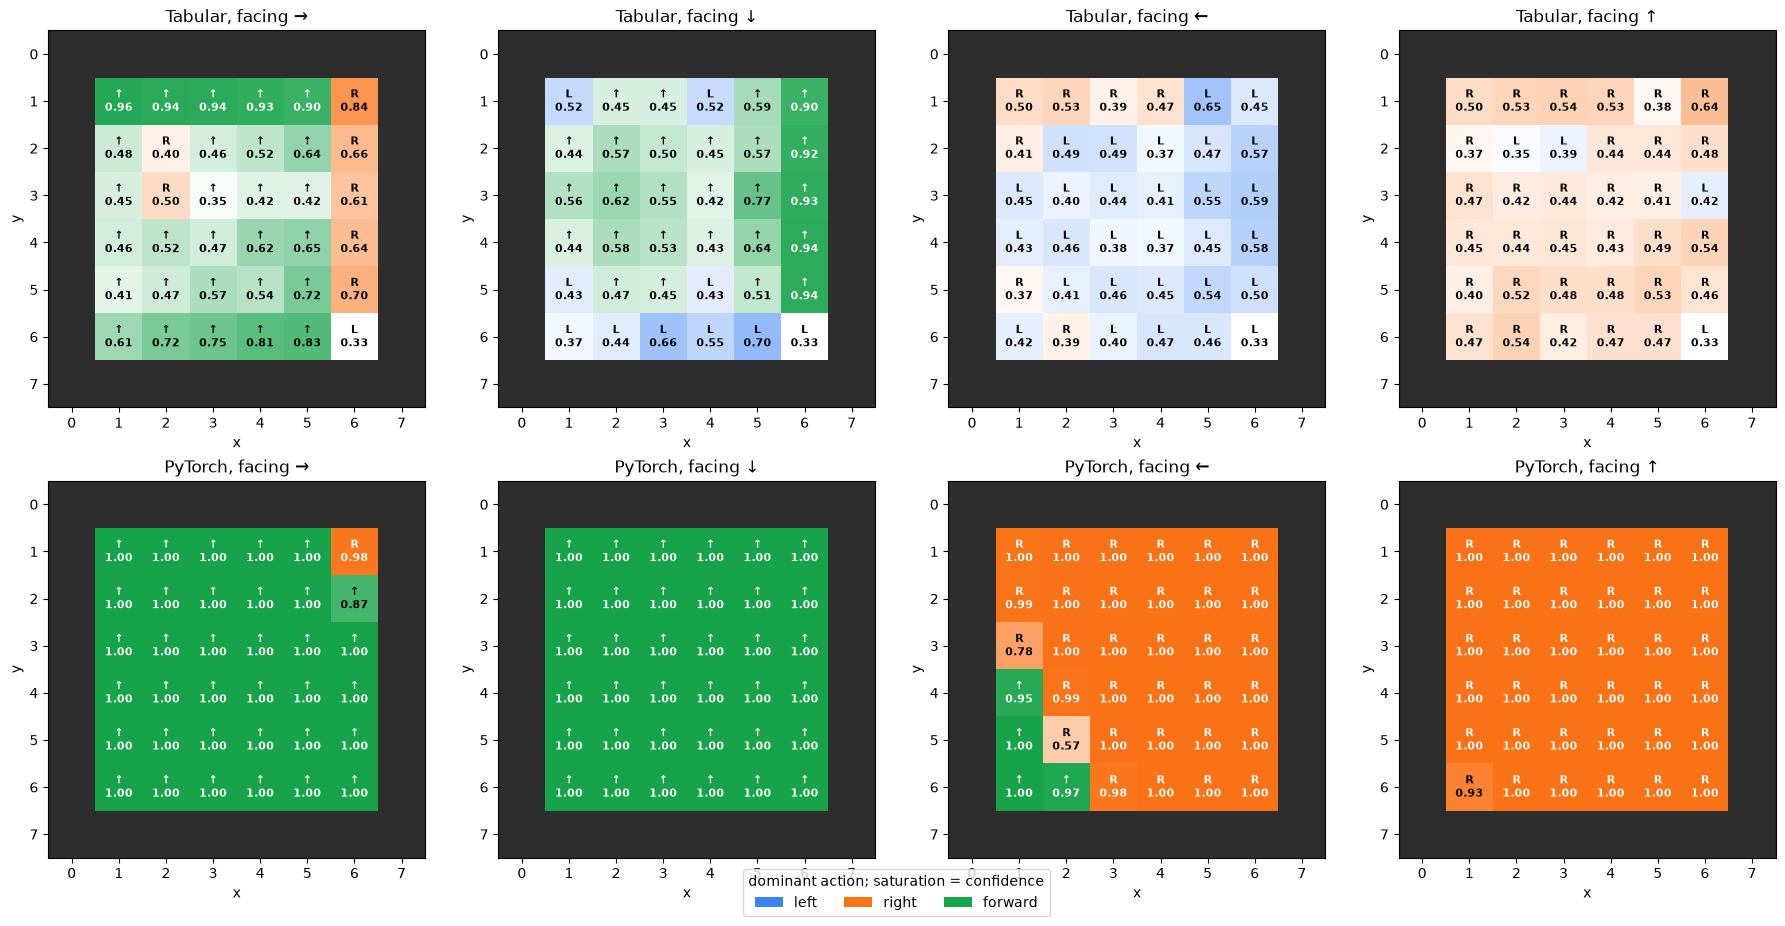

 Tabular | max-action probability min/median/max=0.3333/0.4740/0.9584 | mean normalized entropy=0.8746 | dominant actions={'left': 44, 'right': 46, 'forward': 54}
 PyTorch | max-action probability min/median/max=0.5724/1.0000/1.0000 | mean normalized entropy=0.0176 | dominant actions={'left': 0, 'right': 69, 'forward': 75}


In [12]:
policy_map_env = make_env()
policy_map_env.reset(seed=SEED)
width = policy_map_env.unwrapped.width
height = policy_map_env.unwrapped.height
wall_mask = np.zeros((height, width), dtype=bool)
for x in range(width):
    for y in range(height):
        obj = policy_map_env.unwrapped.grid.get(x, y)
        wall_mask[y, x] = obj is not None and obj.type == "wall"


def tabular_probabilities(state):
    return stable_softmax(tabular_result.preferences[state])


def neural_probabilities(state):
    with torch.no_grad():
        logits = neural_result.model(state_features(state))
        return torch.softmax(logits, dim=-1).cpu().numpy()


from matplotlib.patches import Patch


ACTION_RGB = np.array(
    [
        [0.23, 0.51, 0.96],  # left: blue
        [0.98, 0.45, 0.09],  # right: orange
        [0.09, 0.64, 0.29],  # forward: green
    ]
)
WALL_RGB = np.array([0.18, 0.18, 0.18])


def draw_probability_map(axis, probability_function, direction, title):
    rgb_map = np.full((height, width, 3), WALL_RGB, dtype=float)
    labels = {}
    records = []
    for x in range(width):
        for y in range(height):
            if wall_mask[y, x]:
                continue
            probabilities = np.asarray(
                probability_function((x, y, direction)), dtype=float
            )
            probabilities /= probabilities.sum()
            best_action = int(np.argmax(probabilities))
            confidence = float(probabilities[best_action])
            normalized_entropy = float(
                -np.sum(probabilities * np.log(probabilities + 1e-12))
                / np.log(len(probabilities))
            )
            saturation = np.clip(
                (confidence - 1 / len(probabilities))
                / (1 - 1 / len(probabilities)),
                0.0,
                1.0,
            )
            rgb_map[y, x] = (
                (1 - saturation) * np.ones(3)
                + saturation * ACTION_RGB[best_action]
            )
            labels[(x, y)] = (
                ACTION_SYMBOLS[best_action], confidence, rgb_map[y, x]
            )
            records.append((confidence, normalized_entropy, best_action))

    axis.imshow(rgb_map, origin="upper")
    for (x, y), (symbol, confidence, color) in labels.items():
        luminance = float(
            0.2126 * color[0] + 0.7152 * color[1] + 0.0722 * color[2]
        )
        text_color = "black" if luminance > 0.58 else "white"
        axis.text(
            x,
            y,
            f"{symbol}\n{confidence:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold",
        )
    axis.set_title(title)
    axis.set_xticks(range(width))
    axis.set_yticks(range(height))
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    return records


def print_policy_map_diagnostics(label, records):
    confidence = np.array([record[0] for record in records])
    normalized_entropy = np.array([record[1] for record in records])
    actions = np.array([record[2] for record in records])
    counts = {
        ACTION_NAMES[action]: int(np.sum(actions == action))
        for action in range(len(ACTION_NAMES))
    }
    print(
        f"{label:>8} | max-action probability "
        f"min/median/max={confidence.min():.4f}/"
        f"{np.median(confidence):.4f}/{confidence.max():.4f} | "
        f"mean normalized entropy={normalized_entropy.mean():.4f} | "
        f"dominant actions={counts}"
    )


fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
tabular_map_records = []
neural_map_records = []
for direction in range(4):
    tabular_map_records.extend(draw_probability_map(
        axes[0, direction],
        tabular_probabilities,
        direction,
        f"Tabular, facing {DIRECTION_SYMBOLS[direction]}",
    ))
    neural_map_records.extend(draw_probability_map(
        axes[1, direction],
        neural_probabilities,
        direction,
        f"PyTorch, facing {DIRECTION_SYMBOLS[direction]}",
    ))
legend_handles = [
    Patch(facecolor=ACTION_RGB[index], label=ACTION_NAMES[index])
    for index in range(len(ACTION_NAMES))
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(ACTION_NAMES),
    title="dominant action; saturation = confidence",
    bbox_to_anchor=(0.5, -0.02),
)
plt.show()
print_policy_map_diagnostics("Tabular", tabular_map_records)
print_policy_map_diagnostics("PyTorch", neural_map_records)
policy_map_env.close()

Actions: forward → forward → forward → forward → forward → right → forward → forward → forward → forward → forward
Reward=0.961, steps=11, success=True


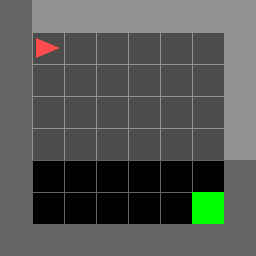

In [13]:
neural_demo = pytorch_policy_rollout(
    neural_result.model,
    seed=2026,
    greedy=True,
    capture_frames=True,
)
neural_gif = ARTIFACT_DIR / "minigrid_pytorch_reinforce.gif"
imageio.mimsave(
    neural_gif, neural_demo["frames"], fps=5, loop=0
)

print(
    "Actions:",
    " → ".join(ACTION_NAMES[action] for action in neural_demo["actions"]),
)
print(
    f"Reward={neural_demo['reward']:.3f}, steps={neural_demo['steps']}, "
    f"success={neural_demo['success']}"
)
display(Image(filename=str(neural_gif)))

## 6. CartPole-v1

Next we validating a new REINFORCE implementation on CartPole before moving to a harder environment. A small control task makes integration bugs easier to distinguish from genuine learning difficulty.

CartPole provides four continuous state values:

1. cart position
2. cart velocity
3. pole angle
4. pole angular velocity

The two actions push the cart left or right. The environment awards $+1$ for every balanced step, terminates when position or angle leaves the safe range, and truncates at 500 steps. Unlike sparse-reward MiniGrid, CartPole supplies a dense learning signal.

The reusable trainer below follows the Hugging Face implementation: sample from a categorical policy, compute return-to-go backward in $O(T)$ time, standardize returns within the episode, and minimize $-G_t\log\pi_\theta(A_t\mid S_t)$. It uses Gymnasium's modern terminated/truncated interface.

In [14]:
@dataclass
class VectorReinforceResult:
    model: nn.Module
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    losses: np.ndarray
    entropies: np.ndarray


class VectorPolicyNetwork(nn.Module):
    def __init__(self, input_size, action_size, hidden_sizes=(64,)):
        super().__init__()
        layers = []
        previous_size = input_size
        for hidden_size in hidden_sizes:
            layers.extend(
                [nn.Linear(previous_size, hidden_size), nn.ReLU()]
            )
            previous_size = hidden_size
        layers.append(nn.Linear(previous_size, action_size))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features)


def standardized_returns(rewards, gamma):
    discounted_return = 0.0
    returns_to_go = []
    for reward in reversed(rewards):
        discounted_return = float(reward) + gamma * discounted_return
        returns_to_go.append(discounted_return)
    returns = torch.tensor(
        list(reversed(returns_to_go)), dtype=torch.float32
    )
    return (returns - returns.mean()) / (
        returns.std(unbiased=False) + np.finfo(np.float32).eps
    )


def train_vector_reinforce(
    env_factory,
    preprocess_observation,
    episodes,
    hidden_sizes,
    learning_rate,
    gamma,
    max_steps,
    seed,
    print_every,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    probe_env = env_factory()
    initial_observation, _ = probe_env.reset(seed=seed)
    input_size = len(preprocess_observation(initial_observation))
    action_size = probe_env.action_space.n
    probe_env.close()

    env = env_factory()
    model = VectorPolicyNetwork(input_size, action_size, hidden_sizes)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    losses = np.zeros(episodes, dtype=float)
    entropies = np.zeros(episodes, dtype=float)

    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        saved_log_probabilities = []
        saved_entropies = []
        rewards = []

        for step in range(1, max_steps + 1):
            features = torch.as_tensor(
                preprocess_observation(observation), dtype=torch.float32
            )
            distribution = Categorical(logits=model(features))
            action = distribution.sample()
            observation, reward, terminated, truncated, _ = env.step(
                int(action.item())
            )
            saved_log_probabilities.append(distribution.log_prob(action))
            saved_entropies.append(distribution.entropy())
            rewards.append(float(reward))
            if terminated or truncated:
                break

        returns = standardized_returns(rewards, gamma)
        log_probabilities = torch.stack(saved_log_probabilities)
        loss = -torch.sum(log_probabilities * returns)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        episode_returns[episode] = sum(rewards)
        episode_lengths[episode] = len(rewards)
        losses[episode] = float(loss.detach())
        entropies[episode] = float(torch.stack(saved_entropies).mean().detach())

        if (episode + 1) % print_every == 0:
            print(
                f"Episode {episode + 1:>5}/{episodes} | "
                f"mean score={episode_returns[max(0, episode - 99):episode + 1].mean():.2f} | "
                f"mean length={episode_lengths[max(0, episode - 99):episode + 1].mean():.1f}"
            )

    env.close()
    return VectorReinforceResult(
        model, episode_returns, episode_lengths, losses, entropies
    )


def vector_policy_rollout(
    env_factory,
    preprocess_observation,
    model,
    seed,
    max_steps,
    greedy=False,
    capture_frames=False,
):
    env = env_factory(render_mode="rgb_array" if capture_frames else None)
    observation, _ = env.reset(seed=seed)
    torch.manual_seed(seed)
    frames = [env.render().copy()] if capture_frames else []
    actions = []
    total_reward = 0.0
    terminated = truncated = False
    model.eval()

    with torch.no_grad():
        for _ in range(max_steps):
            features = torch.as_tensor(
                preprocess_observation(observation), dtype=torch.float32
            )
            logits = model(features)
            action = (
                int(torch.argmax(logits).item())
                if greedy
                else int(Categorical(logits=logits).sample().item())
            )
            observation, reward, terminated, truncated, _ = env.step(action)
            actions.append(action)
            total_reward += float(reward)
            if capture_frames:
                frames.append(env.render().copy())
            if terminated or truncated:
                break

    env.close()
    return {
        "reward": total_reward,
        "steps": len(actions),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "actions": actions,
        "frames": frames,
    }


def evaluate_vector_policy(
    env_factory,
    preprocess_observation,
    model,
    episodes,
    seed,
    max_steps,
    greedy,
):
    rollouts = [
        vector_policy_rollout(
            env_factory,
            preprocess_observation,
            model,
            seed + episode,
            max_steps,
            greedy=greedy,
        )
        for episode in range(episodes)
    ]
    return {
        "rewards": np.asarray([item["reward"] for item in rollouts]),
        "lengths": np.asarray([item["steps"] for item in rollouts]),
    }

In [15]:
CARTPOLE_ENV_NAME = "CartPole-v1"
CARTPOLE_FEATURE_NAMES = (
    "cart position",
    "cart velocity",
    "pole angle",
    "pole angular velocity",
)


def cartpole_factory(render_mode=None):
    return gym.make(CARTPOLE_ENV_NAME, render_mode=render_mode)


def cartpole_preprocess(observation):
    return np.asarray(observation, dtype=np.float32)


cartpole_preview = cartpole_factory()
cartpole_observation, _ = cartpole_preview.reset(seed=SEED)
print("Environment:", CARTPOLE_ENV_NAME)
print("Observation space:", cartpole_preview.observation_space)
print("Action space:", cartpole_preview.action_space)
print(
    "Initial observation:",
    dict(zip(CARTPOLE_FEATURE_NAMES, np.round(cartpole_observation, 4))),
)
cartpole_preview.close()

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: {'cart position': np.float32(0.0345), 'cart velocity': np.float32(-0.0339), 'pole angle': np.float32(0.0058), 'pole angular velocity': np.float32(-0.0132)}


Episode   250/1000 | mean score=139.47 | mean length=139.5


Episode   500/1000 | mean score=231.30 | mean length=231.3


Episode   750/1000 | mean score=476.13 | mean length=476.1


Episode  1000/1000 | mean score=493.43 | mean length=493.4


CartPole stochastic: reward=469.86 ± 78.62, mean steps=469.86
CartPole     greedy: reward=500.00 ± 0.00, mean steps=500.00


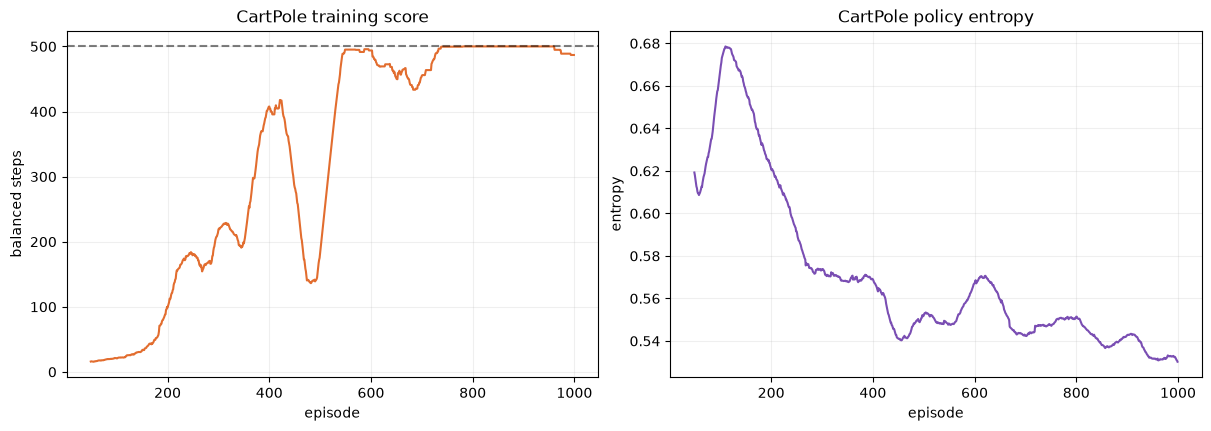

CartPole demo: reward=500.0, steps=500, truncated=True


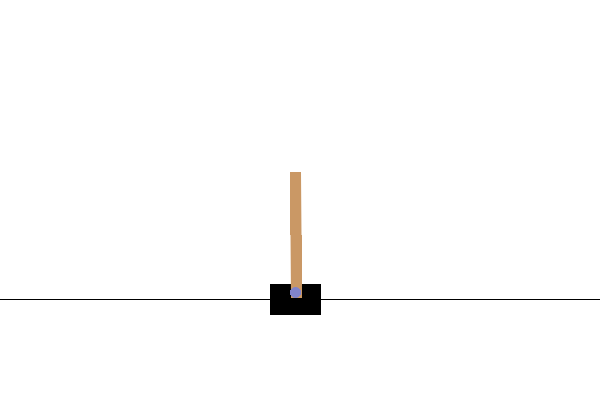

In [16]:
cartpole_result = train_vector_reinforce(
    env_factory=cartpole_factory,
    preprocess_observation=cartpole_preprocess,
    episodes=1000,
    hidden_sizes=(16,),
    learning_rate=1e-2,
    gamma=1.0,
    max_steps=500,
    seed=SEED,
    print_every=250,
)

cartpole_stochastic_evaluation = evaluate_vector_policy(
    cartpole_factory,
    cartpole_preprocess,
    cartpole_result.model,
    episodes=50,
    seed=5000,
    max_steps=500,
    greedy=False,
)
cartpole_greedy_evaluation = evaluate_vector_policy(
    cartpole_factory,
    cartpole_preprocess,
    cartpole_result.model,
    episodes=50,
    seed=6000,
    max_steps=500,
    greedy=True,
)

for label, evaluation in [
    ("stochastic", cartpole_stochastic_evaluation),
    ("greedy", cartpole_greedy_evaluation),
]:
    print(
        f"CartPole {label:>10}: "
        f"reward={evaluation['rewards'].mean():.2f} ± {evaluation['rewards'].std():.2f}, "
        f"mean steps={evaluation['lengths'].mean():.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
cartpole_x, cartpole_score_mean = moving_average(
    cartpole_result.episode_returns, window=50
)
_, cartpole_entropy_mean = moving_average(
    cartpole_result.entropies, window=50
)
axes[0].plot(cartpole_x, cartpole_score_mean, color="#e26d2f")
axes[0].axhline(500, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("CartPole training score")
axes[0].set_ylabel("balanced steps")
axes[1].plot(cartpole_x, cartpole_entropy_mean, color="#7a4eb3")
axes[1].set_title("CartPole policy entropy")
axes[1].set_ylabel("entropy")
for axis in axes:
    axis.set_xlabel("episode")
    axis.grid(alpha=0.2)
plt.show()

cartpole_demo = vector_policy_rollout(
    cartpole_factory,
    cartpole_preprocess,
    cartpole_result.model,
    seed=2026,
    max_steps=500,
    greedy=True,
    capture_frames=True,
)
cartpole_gif = ARTIFACT_DIR / "cartpole_reinforce.gif"
imageio.mimsave(
    cartpole_gif, cartpole_demo["frames"][::2], fps=30, loop=0
)
print(
    f"CartPole demo: reward={cartpole_demo['reward']:.1f}, "
    f"steps={cartpole_demo['steps']}, truncated={cartpole_demo['truncated']}"
)
display(Image(filename=str(cartpole_gif)))

## 7. Experiment 3: PixelCopter

PixelCopter comes from the [PyGame Learning Environment](https://pygame-learning-environment.readthedocs.io/en/latest/user/games/pixelcopter.html). The Hugging Face hands-on accesses it through the legacy Gym environment Pixelcopter-PLE-v0. That integration still uses the old reset/step API, so this notebook provides a small Gymnasium adapter with reproducible reset seeds and separate terminated/truncated flags.

Despite its name, the Hugging Face experiment does **not** train from RGB pixels. Its policy receives seven state features: player height and velocity, distance to ceiling and floor, horizontal distance to the next gate, and the gate's upper and lower boundaries. RGB frames are used only for visualization.

The two actions are accelerate upward and do nothing. Passing a gate gives $+1$ and crashing gives $-1$. This event-based reward is less dense than CartPole and the environment is more variable, so the policy uses two hidden layers and a longer classroom training run. Hugging Face uses 50,000 episodes for its full benchmark; we use 5,000 to keep the notebook practical and report the resulting score honestly.

In [17]:
PIXELCOPTER_STATE_KEYS = (
    "player_y",
    "player_vel",
    "player_dist_to_ceil",
    "player_dist_to_floor",
    "next_gate_dist_to_player",
    "next_gate_block_top",
    "next_gate_block_bottom",
)
PIXELCOPTER_ACTION_NAMES = ("accelerate up", "do nothing")
PIXELCOPTER_SCALE = np.array([48, 10, 48, 48, 48, 48, 48], dtype=np.float32)


class PixelcopterGymnasiumEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"], "render_fps": 30}

    def __init__(self, render_mode=None, max_episode_steps=1000, seed=0):
        self.render_mode = render_mode
        self.max_episode_steps = max_episode_steps
        self.game = Pixelcopter(width=48, height=48)
        self.ple = PLE(
            self.game,
            fps=30,
            display_screen=False,
            force_fps=True,
            rng=seed,
        )
        self.ple_actions = self.ple.getActionSet()
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32,
        )
        self.steps = 0

    def _observation(self):
        state = self.ple.getGameState()
        return np.asarray(
            [state[key] for key in PIXELCOPTER_STATE_KEYS],
            dtype=np.float32,
        )

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.ple.rng.seed(seed)
            self.game.setRNG(self.ple.rng)
            self.action_space.seed(seed)
        self.ple.reset_game()
        self.steps = 0
        return self._observation(), {}

    def step(self, action):
        reward = float(self.ple.act(self.ple_actions[int(action)]))
        self.steps += 1
        terminated = bool(self.ple.game_over())
        truncated = bool(
            self.steps >= self.max_episode_steps and not terminated
        )
        return self._observation(), reward, terminated, truncated, {}

    def render(self):
        return self.ple.getScreenRGB().copy()

    def close(self):
        pass


def pixelcopter_factory(render_mode=None):
    return PixelcopterGymnasiumEnv(
        render_mode=render_mode, max_episode_steps=1000
    )


def pixelcopter_preprocess(observation):
    return np.asarray(observation, dtype=np.float32) / PIXELCOPTER_SCALE


pixelcopter_preview = pixelcopter_factory()
pixelcopter_observation, _ = pixelcopter_preview.reset(seed=SEED)
print("Observation space:", pixelcopter_preview.observation_space)
print("Action mapping:", dict(enumerate(PIXELCOPTER_ACTION_NAMES)))
print(
    "Initial observation:",
    dict(zip(PIXELCOPTER_STATE_KEYS, pixelcopter_observation)),
)
pixelcopter_preview.close()

Observation space: Box(-inf, inf, (7,), float32)
Action mapping: {0: 'accelerate up', 1: 'do nothing'}
Initial observation: {'player_y': np.float32(24.0), 'player_vel': np.float32(0.0), 'player_dist_to_ceil': np.float32(7.0), 'player_dist_to_floor': np.float32(17.0), 'next_gate_dist_to_player': np.float32(47.0), 'next_gate_block_top': np.float32(29.0), 'next_gate_block_bottom': np.float32(38.0)}


Episode  1000/5000 | mean score=-0.70 | mean length=33.0


Episode  2000/5000 | mean score=0.21 | mean length=37.9


Episode  3000/5000 | mean score=1.27 | mean length=44.9


Episode  4000/5000 | mean score=3.05 | mean length=55.1


Episode  5000/5000 | mean score=6.23 | mean length=73.8
Last-100 PixelCopter score: 6.23 | mean steps: 73.8


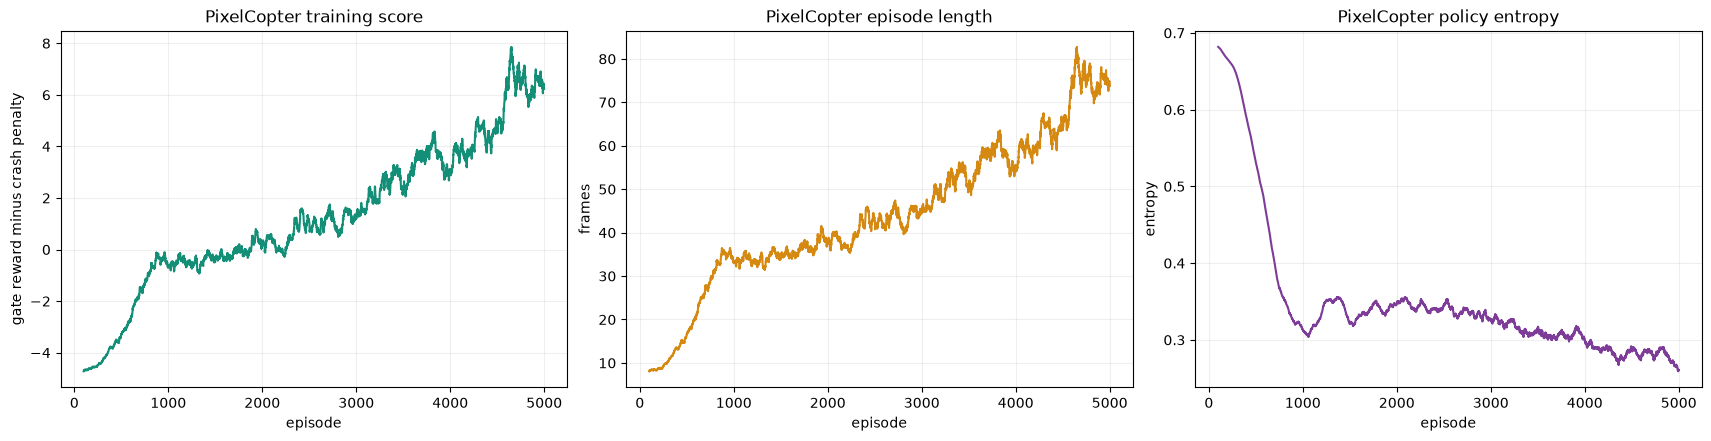

In [18]:
pixelcopter_result = train_vector_reinforce(
    env_factory=pixelcopter_factory,
    preprocess_observation=pixelcopter_preprocess,
    episodes=5000,
    hidden_sizes=(64, 128),
    learning_rate=1e-4,
    gamma=0.99,
    max_steps=1000,
    seed=50,
    print_every=1000,
)

print(
    f"Last-100 PixelCopter score: "
    f"{pixelcopter_result.episode_returns[-100:].mean():.2f} | "
    f"mean steps: {pixelcopter_result.episode_lengths[-100:].mean():.1f}"
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), constrained_layout=True)
pixel_x, pixel_score_mean = moving_average(
    pixelcopter_result.episode_returns, window=100
)
_, pixel_length_mean = moving_average(
    pixelcopter_result.episode_lengths, window=100
)
_, pixel_entropy_mean = moving_average(
    pixelcopter_result.entropies, window=100
)
axes[0].plot(pixel_x, pixel_score_mean, color="#148f77")
axes[0].set_title("PixelCopter training score")
axes[0].set_ylabel("gate reward minus crash penalty")
axes[1].plot(pixel_x, pixel_length_mean, color="#d68910")
axes[1].set_title("PixelCopter episode length")
axes[1].set_ylabel("frames")
axes[2].plot(pixel_x, pixel_entropy_mean, color="#7d3c98")
axes[2].set_title("PixelCopter policy entropy")
axes[2].set_ylabel("entropy")
for axis in axes:
    axis.set_xlabel("episode")
    axis.grid(alpha=0.2)
plt.show()

PixelCopter stochastic: reward=7.30 ± 11.94, mean steps=79.4
PixelCopter     greedy: reward=-2.00 ± 0.73, mean steps=24.2
Representative stochastic rollout: seed=10024, reward=3.0, steps=58


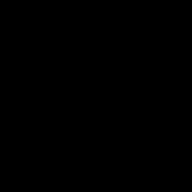

In [19]:
pixelcopter_stochastic_evaluation = evaluate_vector_policy(
    pixelcopter_factory,
    pixelcopter_preprocess,
    pixelcopter_result.model,
    episodes=30,
    seed=10_000,
    max_steps=1000,
    greedy=False,
)
pixelcopter_greedy_evaluation = evaluate_vector_policy(
    pixelcopter_factory,
    pixelcopter_preprocess,
    pixelcopter_result.model,
    episodes=30,
    seed=20_000,
    max_steps=1000,
    greedy=True,
)

for label, evaluation in [
    ("stochastic", pixelcopter_stochastic_evaluation),
    ("greedy", pixelcopter_greedy_evaluation),
]:
    print(
        f"PixelCopter {label:>10}: "
        f"reward={evaluation['rewards'].mean():.2f} ± {evaluation['rewards'].std():.2f}, "
        f"mean steps={evaluation['lengths'].mean():.1f}"
    )

ordered_indices = np.argsort(pixelcopter_stochastic_evaluation["rewards"])
representative_index = int(ordered_indices[len(ordered_indices) // 2])
representative_seed = 10_000 + representative_index
pixelcopter_demo = vector_policy_rollout(
    pixelcopter_factory,
    pixelcopter_preprocess,
    pixelcopter_result.model,
    seed=representative_seed,
    max_steps=1000,
    greedy=False,
    capture_frames=True,
)
pixelcopter_gif = ARTIFACT_DIR / "pixelcopter_reinforce.gif"
pixelcopter_frames = [
    np.repeat(np.repeat(frame, 4, axis=0), 4, axis=1)
    for frame in pixelcopter_demo["frames"]
]
imageio.mimsave(
    pixelcopter_gif, pixelcopter_frames, fps=30, loop=0
)
print(
    f"Representative stochastic rollout: seed={representative_seed}, "
    f"reward={pixelcopter_demo['reward']:.1f}, "
    f"steps={pixelcopter_demo['steps']}"
)
display(Image(filename=str(pixelcopter_gif)))

## 8. What the Three Environments Reveal

| Environment | Policy input | Actions | Reward character | Main lesson |
|---|---:|---:|---|---|
| MiniGrid Empty | 6 engineered features | 3 | sparse terminal reward | exploration may take many episodes before the first useful trajectory |
| CartPole-v1 | 4 continuous state values | 2 | dense $+1$ per step | a small environment is ideal for debugging the implementation |
| PixelCopter | 7 normalized game-state values | 2 | gate events and crash penalty | longer training and stochastic evaluation matter |

The network architecture changes with input complexity, but the estimator does not: sample actions, retain log probabilities, compute return-to-go, and update the policy from the negative weighted log likelihood.

The Hugging Face certification score is mean reward minus reward standard deviation. We print that conservative statistic below, but this shorter classroom PixelCopter run is a demonstration rather than the course's 50,000-episode benchmark.

     environment | obs | act | episodes |       mode |    reward mean ± std
--------------------------------------------------------------------------------
  MiniGrid Empty |   6 |   3 |      800 |     greedy |     0.96 ± 0.00    
     CartPole-v1 |   4 |   2 |     1000 | stochastic |   469.86 ± 78.62   
     PixelCopter |   7 |   2 |     5000 | stochastic |     7.30 ± 11.94   

CartPole mean - std: 391.24
PixelCopter mean - std: -4.64


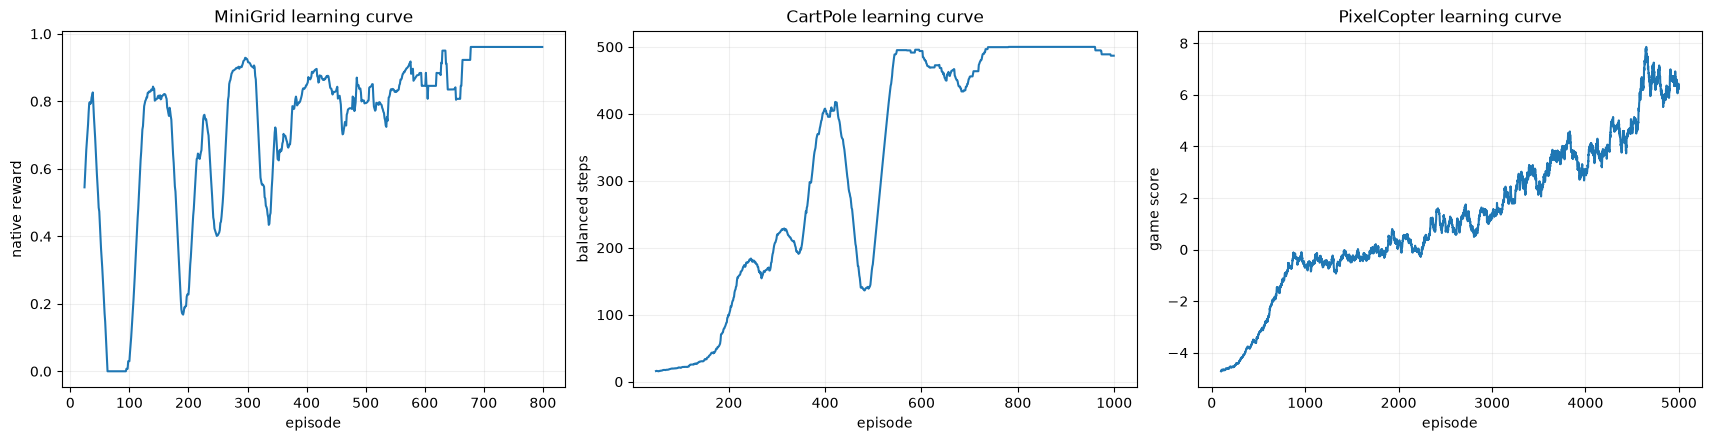

In [20]:
minigrid_cross_metrics = evaluate_neural_policy(
    neural_result.model, greedy=True, episodes=100, seed=30_000
)

summary_rows = [
    (
        "MiniGrid Empty",
        6,
        3,
        800,
        "greedy",
        minigrid_cross_metrics["reward"],
        0.0,
    ),
    (
        "CartPole-v1",
        4,
        2,
        1000,
        "stochastic",
        cartpole_stochastic_evaluation["rewards"].mean(),
        cartpole_stochastic_evaluation["rewards"].std(),
    ),
    (
        "PixelCopter",
        7,
        2,
        5000,
        "stochastic",
        pixelcopter_stochastic_evaluation["rewards"].mean(),
        pixelcopter_stochastic_evaluation["rewards"].std(),
    ),
]

print(
    f"{'environment':>16} | {'obs':>3} | {'act':>3} | "
    f"{'episodes':>8} | {'mode':>10} | {'reward mean ± std':>20}"
)
print("-" * 80)
for environment, obs_size, action_size, episodes, mode, mean, std in summary_rows:
    print(
        f"{environment:>16} | {obs_size:>3} | {action_size:>3} | "
        f"{episodes:>8} | {mode:>10} | {mean:>8.2f} ± {std:<8.2f}"
    )

cartpole_conservative_score = (
    cartpole_stochastic_evaluation["rewards"].mean()
    - cartpole_stochastic_evaluation["rewards"].std()
)
pixelcopter_conservative_score = (
    pixelcopter_stochastic_evaluation["rewards"].mean()
    - pixelcopter_stochastic_evaluation["rewards"].std()
)
print(f"\nCartPole mean - std: {cartpole_conservative_score:.2f}")
print(f"PixelCopter mean - std: {pixelcopter_conservative_score:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), constrained_layout=True)
training_series = [
    (neural_result.episode_returns, 25, "MiniGrid", "native reward"),
    (cartpole_result.episode_returns, 50, "CartPole", "balanced steps"),
    (pixelcopter_result.episode_returns, 100, "PixelCopter", "game score"),
]
for axis, (values, window, title, ylabel) in zip(axes, training_series):
    x_values, smooth_values = moving_average(values, window=window)
    axis.plot(x_values, smooth_values)
    axis.set_title(f"{title} learning curve")
    axis.set_xlabel("episode")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.2)
plt.show()

## 9. From Tabular Preferences to Neural Policies

| Component | Tabular softmax policy | PyTorch policy network |
|---|---|---|
| State representation | Direct $(x,y,d)$ index | Environment-specific feature vector |
| Parameters | One preference vector per state | Shared neural-network weights |
| Action distribution | NumPy softmax | PyTorch Categorical distribution |
| Gradient | Written analytically | Computed by autograd |
| Generalization | None between table entries | Possible through shared features |
| Optimization | Direct gradient-ascent update | Adam minimizes a negative objective |

PyTorch does not change the policy-gradient theorem. It changes how $\pi_\theta$ is represented and how its derivatives are computed.

For image observations, the same interface can use a convolutional encoder. For continuous actions, a policy can output the mean and scale of a Gaussian distribution. Adding a learned value baseline produces an **actor–critic** method: the policy is the actor and the value estimator is the critic.

## 10. Practical Checks and Common Failure Modes

- **Use logits with Categorical.** Applying softmax twice distorts the distribution.
- **Keep log probabilities attached to the graph.** Converting them to NumPy during the episode removes the gradient path.
- **Do not differentiate through the environment.** Environment rewards are numerical weights for log probabilities.
- **Distinguish termination from truncation.** Both end a sampled trajectory, but only termination represents task completion.
- **Track entropy and success together.** Very early entropy collapse can stop exploration.
- **Evaluate the policy distribution and its greedy mode.** They answer different questions.
- **Set seeds for comparisons.** Policy-gradient estimates have high variance, so matched conditions matter.
- **Inspect rollouts.** A high shaped or surrogate objective does not guarantee the intended behavior.

## Conclusions

In this lab, you completed the policy-learning path from explicit probabilities to a neural stochastic policy:

- Converted action preferences into stable softmax probabilities
- Derived and implemented the REINFORCE update
- Used return-to-go and a state baseline in a tabular policy
- Built a PyTorch policy network with shared parameters
- Optimized return-weighted log probabilities using automatic differentiation
- Monitored reward, success, episode length, and entropy
- Compared stochastic and greedy evaluation
- Visualized tabular and neural policy maps and GIF rollouts
- Reused a Hugging Face-style REINFORCE trainer on CartPole and PixelCopter
- Compared dense, sparse, and event-based reward signals
- Modernized the legacy PixelCopter environment with a Gymnasium adapter

The central policy-gradient idea is to **increase the log probability of sampled actions in proportion to how useful their outcomes were**. This estimator is the foundation for actor–critic methods and modern algorithms such as A2C and PPO.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.  
SPDX-License-Identifier: MIT